In [1]:
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df=pd.read_csv("../DATA/raw/truck_data.csv")
df.head()

,Driver_Age,Driving_Hours,Speed,Harsh_Braking,Harsh_Acceleration,Drowsiness_Score,Engine_Temperature,Engine_Vibration,Battery_Voltage,Oil_Pressure,Tyre_Pressure,Vehicle_Age,Mileage,Previous_Breakdowns,Previous_Accidents,Weather,Road_Type,Driver_Risk,Breakdown_Risk
0,50,5.4,47,2,1,65.7,83.1,1.76,13.08,59.9,35.5,6,423852,0,0,Clear,Highway,0,0
1,36,9.3,69,1,0,100.0,97.2,3.68,11.88,38.0,37.8,13,883857,4,0,Rain,City,1,1
2,29,6.0,81,1,2,70.0,93.8,1.98,12.30,50.0,35.3,14,680286,1,0,Clear,Highway,0,0
3,42,5.5,62,1,4,62.2,84.9,4.25,12.90,32.4,36.8,4,289202,0,0,Clear,Highway,0,0
4,40,11.3,55,0,0,100.0,94.0,4.85,12.56,28.9,33.0,11,172552,1,0,Clear,Highway,1,0


In [4]:
df.shape

(5000, 19)

In [5]:
df.isnull().sum()

Driver_Age             0
Driving_Hours          0
Speed                  0
Harsh_Braking          0
Harsh_Acceleration     0
Drowsiness_Score       0
Engine_Temperature     0
Engine_Vibration       0
Battery_Voltage        0
Oil_Pressure           0
Tyre_Pressure          0
Vehicle_Age            0
Mileage                0
Previous_Breakdowns    0
Previous_Accidents     0
Weather                0
Road_Type              0
Driver_Risk            0
Breakdown_Risk         0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Driver_Age,5000.0,40.699800,10.927249,22.00,31.00,41.00,50.00,59.0
Driving_Hours,5000.0,6.413920,3.151414,1.00,3.70,6.30,9.10,12.0
Speed,5000.0,71.753400,21.594153,35.00,53.00,72.00,90.00,109.0
Harsh_Braking,5000.0,2.044600,1.428222,0.00,1.00,2.00,3.00,9.0
Harsh_Acceleration,5000.0,1.979400,1.434917,0.00,1.00,2.00,3.00,10.0
Drowsiness_Score,5000.0,69.227940,24.386468,8.10,49.60,70.40,93.00,100.0
Engine_Temperature,5000.0,92.155340,8.001215,62.10,86.70,92.20,97.60,119.8
Engine_Vibration,5000.0,3.490618,0.992692,0.12,2.81,3.49,4.16,6.7
Battery_Voltage,5000.0,12.606874,0.506319,10.92,12.27,12.61,12.95,14.3
Oil_Pressure,5000.0,41.832140,8.150423,13.70,36.50,41.90,47.10,69.6


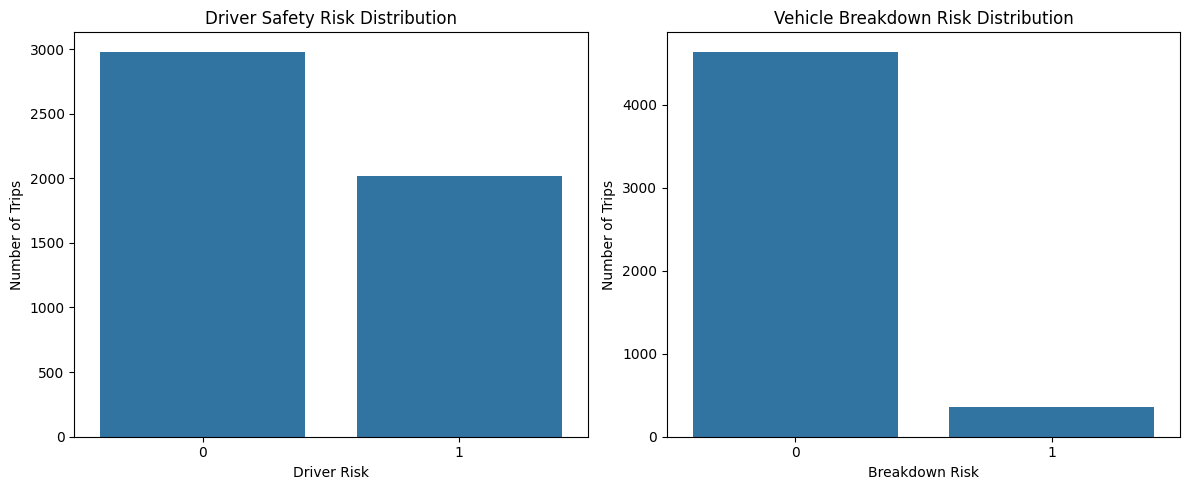

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="Driver_Risk", ax=axes[0])
axes[0].set_title("Driver Safety Risk Distribution")
axes[0].set_xlabel("Driver Risk")
axes[0].set_ylabel("Number of Trips")

sns.countplot(data=df, x="Breakdown_Risk", ax=axes[1])
axes[1].set_title("Vehicle Breakdown Risk Distribution")
axes[1].set_xlabel("Breakdown Risk")
axes[1].set_ylabel("Number of Trips")

plt.tight_layout()

plt.savefig(
    "../REPORTS/FIGURES/target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

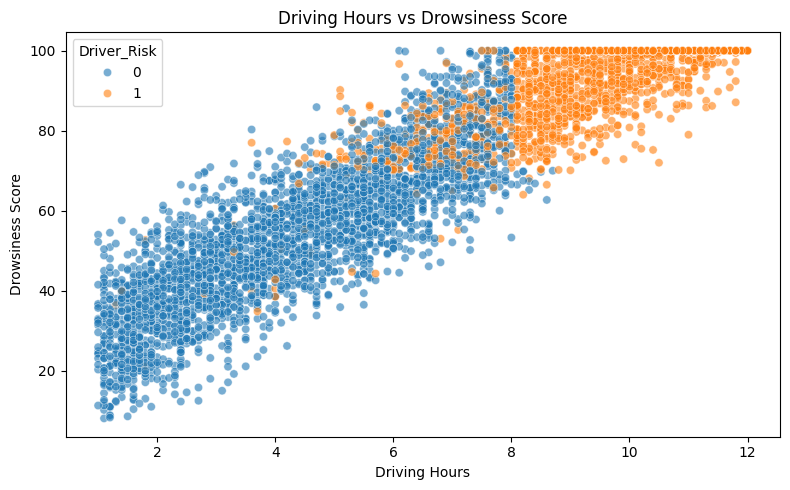

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Driving_Hours",
    y="Drowsiness_Score",
    hue="Driver_Risk",
    alpha=0.6
)

plt.title("Driving Hours vs Drowsiness Score")
plt.xlabel("Driving Hours")
plt.ylabel("Drowsiness Score")

plt.tight_layout()

plt.savefig(
    "../REPORTS/FIGURES/driving_hours_vs_drowsiness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## this graph show that the relationship between driving hourse and drowsiness

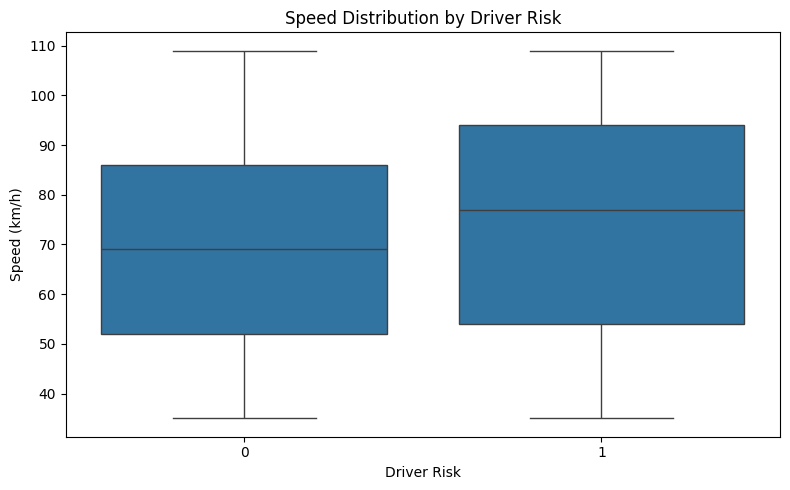

In [12]:
## Speed vs Driver Risk 
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Driver_Risk",
    y="Speed"
)

plt.title("Speed Distribution by Driver Risk")
plt.xlabel("Driver Risk")
plt.ylabel("Speed (km/h)")

plt.tight_layout()

plt.savefig(
    "../REPORTS/FIGURES/speed_vs_driver_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

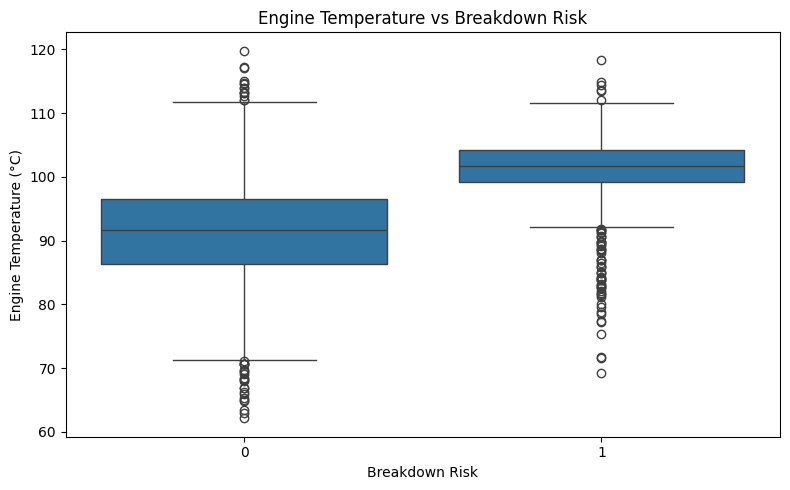

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Breakdown_Risk",
    y="Engine_Temperature"
)

plt.title("Engine Temperature vs Breakdown Risk")
plt.xlabel("Breakdown Risk")
plt.ylabel("Engine Temperature (°C)")

plt.tight_layout()

plt.savefig(
    "../REPORTS/FIGURES/engine_temperature_vs_breakdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

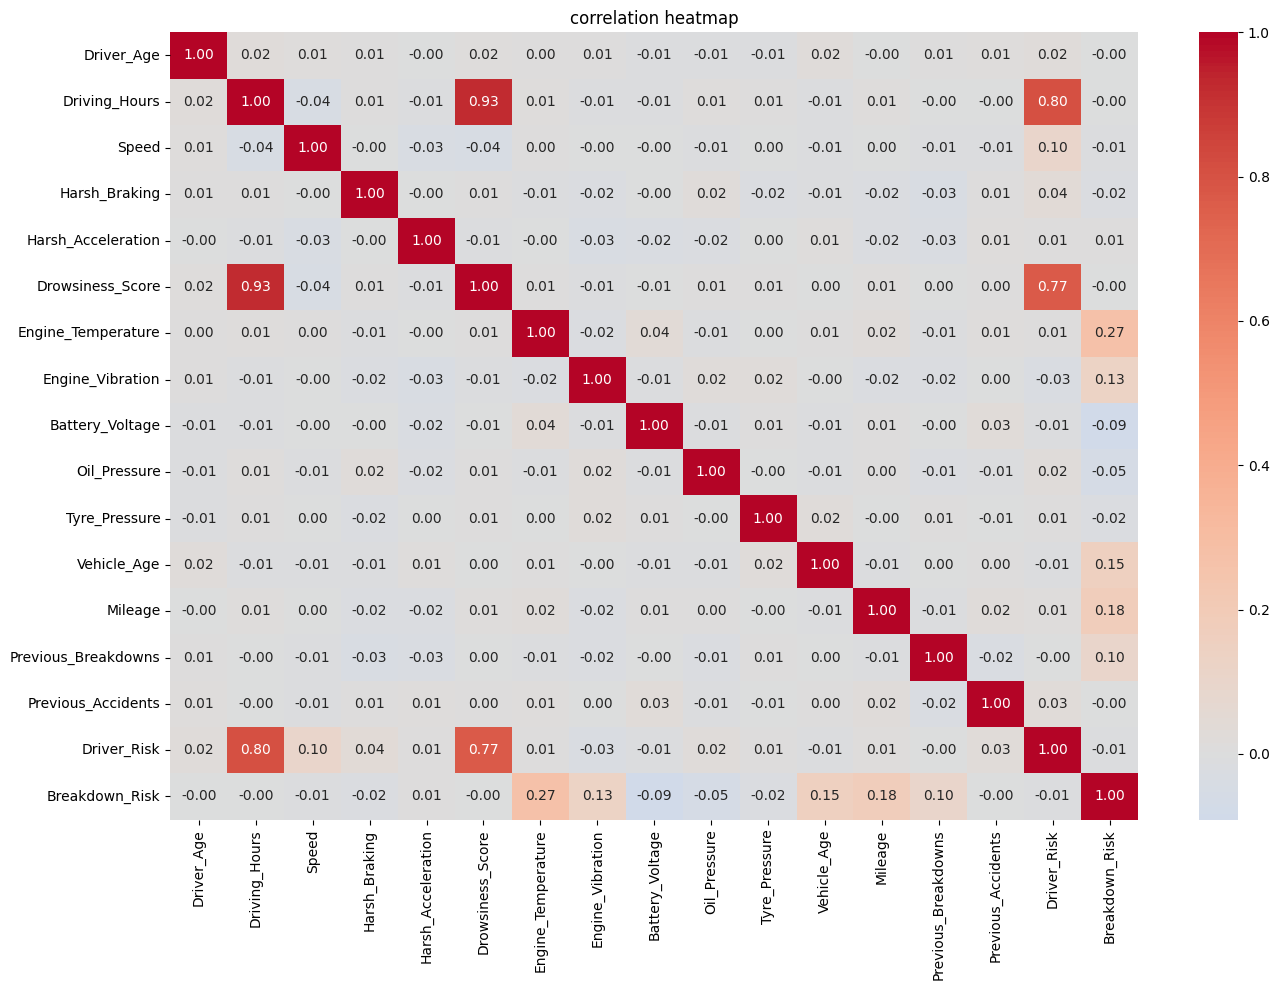

In [14]:
numeric_df=df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("correlation heatmap") 

plt.tight_layout()

plt.savefig(
    "../REPORTS/FIGURES/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show() 

In [15]:
df.columns

Index(['Driver_Age', 'Driving_Hours', 'Speed', 'Harsh_Braking',
       'Harsh_Acceleration', 'Drowsiness_Score', 'Engine_Temperature',
       'Engine_Vibration', 'Battery_Voltage', 'Oil_Pressure', 'Tyre_Pressure',
       'Vehicle_Age', 'Mileage', 'Previous_Breakdowns', 'Previous_Accidents',
       'Weather', 'Road_Type', 'Driver_Risk', 'Breakdown_Risk'],
      dtype='str')

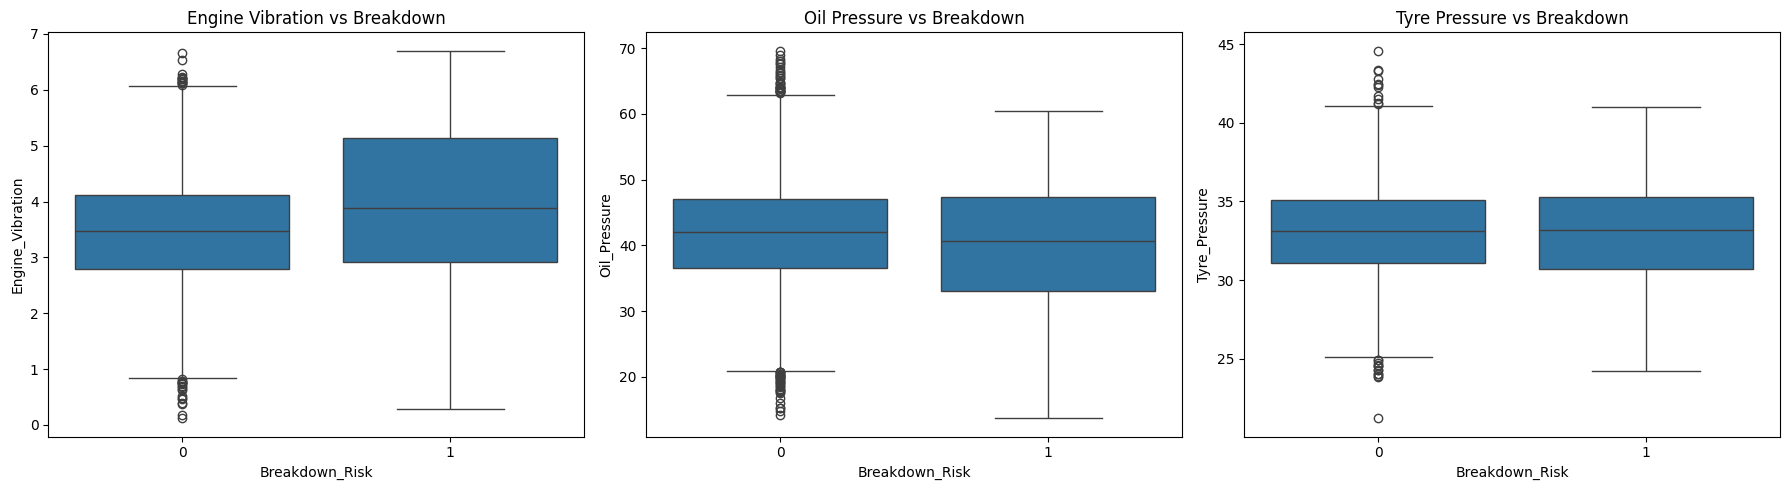

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df,x="Breakdown_Risk",y="Engine_Vibration",ax=axes[0])
axes[0].set_title("Engine Vibration vs Breakdown")

sns.boxplot(data=df,x="Breakdown_Risk",y="Oil_Pressure", ax=axes[1])
axes[1].set_title("Oil Pressure vs Breakdown")

sns.boxplot(data=df,x="Breakdown_Risk",y="Tyre_Pressure",ax=axes[2])
axes[2].set_title("Tyre Pressure vs Breakdown")

plt.tight_layout()

plt.savefig("../REPORTS/FIGURES/vehicle_health_analysis.png",dpi=300,bbox_inches="tight")

plt.show()

In [20]:
print("========== DRIVER RISK ANALYSIS ==========\n")

print(
    df.groupby("Driver_Risk")[
        [
            "Driving_Hours",
            "Speed",
            "Harsh_Braking",
            "Harsh_Acceleration",
            "Drowsiness_Score"
        ]
    ].mean().round(2)
)

print("\n========== BREAKDOWN RISK ANALYSIS ==========\n")

print(
    df.groupby("Breakdown_Risk")[
        [
            "Engine_Temperature",
            "Engine_Vibration",
            "Battery_Voltage",
            "Oil_Pressure",
            "Tyre_Pressure",
            "Vehicle_Age",
            "Mileage"
        ]
    ].mean().round(2)
)

========== DRIVER RISK ANALYSIS ==========

             Driving_Hours  Speed  Harsh_Braking  Harsh_Acceleration  \
Driver_Risk                                                            
0                     4.33  69.97           2.00                1.97   
1                     9.49  74.39           2.11                1.99   

             Drowsiness_Score  
Driver_Risk                    
0                       53.73  
1                       92.09  

========== BREAKDOWN RISK ANALYSIS ==========

                Engine_Temperature  Engine_Vibration  Battery_Voltage  \
Breakdown_Risk                                                          
0                            91.56              3.45            12.62   
1                            99.89              3.96            12.44   

                Oil_Pressure  Tyre_Pressure  Vehicle_Age    Mileage  
Breakdown_Risk                                                       
0                      41.95          33.10         7.99  

In [21]:
df.to_csv(
    "../DATA/processed/truck_processed.csv",
    index=False
)

print("Processed dataset saved successfully ✅")

Processed dataset saved successfully ✅
